In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
# 1. Verification Gate
input_file = "master_feature_table_with_hazards.csv"
if not os.path.exists(input_file):
    raise FileNotFoundError(f"Missing master database table! Please run Notebook 06 first.")

df_master = pd.read_csv(input_file)
print(f"Successfully loaded master feature matrix. Total observations: {len(df_master)}")

Successfully loaded master feature matrix. Total observations: 18260


In [3]:
# 2. Define the exact 12 underlying glass-box driver components we engineered
component_cols = [
    'rain_hazard_component', 'snow_hazard_component', 'wind_hazard_component',
    'distance_hazard_component', 'density_hazard_component', 'terrain_hazard_component',
    'crowd_baseline_component', 'festival_component', 'vacation_component',
    'complexity_component', 'budget_component', 'elevation_component'
]

for col in component_cols:
    assert col in df_master.columns, f"Schema Error: Missing component column '{col}'"
    
print("✅ All 12 explainable driver channels discovered in the schema layout.")

✅ All 12 explainable driver channels discovered in the schema layout.


## Engineered Component Contributions

In [4]:
print("--- CALCULATING RAW SCORING COMPONENT CONTRIBUTIONS ---\n")

# 1. Compute the mathematical mean score of each driver channel across all observations
mean_contributions = df_master[component_cols].mean()

# 2. Convert raw point averages into a relative percentage distribution profile
total_points_allocated = mean_contributions.sum()
relative_importance_percentages = (mean_contributions / total_points_allocated) * 100.0

# 3. Assemble a clean, technically accurate summary table
df_shares = pd.DataFrame({
    "Driver Component": relative_importance_percentages.index,
    "Raw Mean Point Contribution": mean_contributions.values,
    "Global Contribution Share (%)": relative_importance_percentages.values
})

# Sort descending by contribution share
df_shares = df_shares.sort_values(by="Global Contribution Share (%)", ascending=False).reset_index(drop=True)

# Export the summary data sheet directly to disk with the precise naming convention
output_shares_csv = "engine_component_contributions.csv"
df_shares.to_csv(output_shares_csv, index=False)
print(f"🎉 Success! Scoring engine component contributions written to '{output_shares_csv}'.")
df_shares

--- CALCULATING RAW SCORING COMPONENT CONTRIBUTIONS ---

🎉 Success! Scoring engine component contributions written to 'engine_component_contributions.csv'.


,Driver Component,Raw Mean Point Contribution,Global Contribution Share (%)
0,complexity_component,33.015000,28.690503
1,crowd_baseline_component,26.902226,23.378415
2,budget_component,18.240000,15.850818
3,distance_hazard_component,14.269220,12.400154
4,wind_hazard_component,5.227273,4.542574
5,terrain_hazard_component,4.800000,4.171268
6,rain_hazard_component,4.764179,4.140139
7,elevation_component,3.529000,3.066751
8,density_hazard_component,2.100870,1.825686
9,vacation_component,1.670318,1.451530


## Component Visualization — Global Risk Contribution Analysis

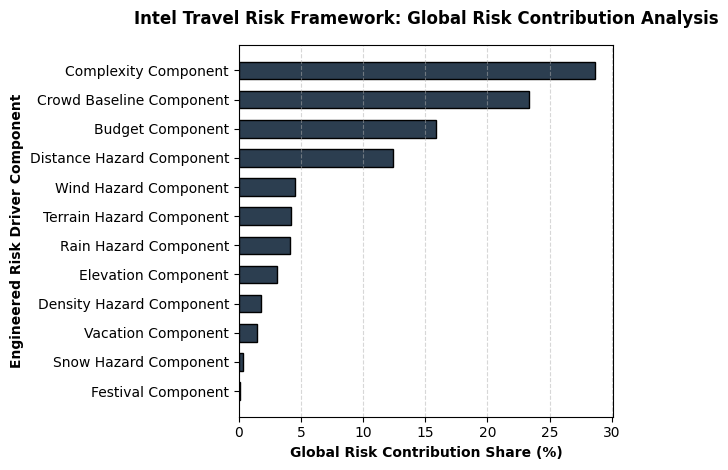

In [5]:
# 1. Sort ascending so the largest contribution displays prominently at the top
df_plot = df_shares.sort_values(by="Global Contribution Share (%)", ascending=True)

# 2. Generate horizontal bars with a clean dark-slate palette
plt.barh(
    df_plot["Driver Component"].map(lambda x: x.replace('_', ' ').title()), 
    df_plot["Global Contribution Share (%)"], 
    color="#2C3E50", 
    edgecolor="black",
    height=0.6
)

# 3. Label axes clearly to ensure readability
plt.xlabel("Global Risk Contribution Share (%)", fontsize=10, fontweight="bold")
plt.ylabel("Engineered Risk Driver Component", fontsize=10, fontweight="bold")
plt.title("Intel Travel Risk Framework: Global Risk Contribution Analysis", fontsize=12, fontweight="bold", pad=15)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# 4. Automatically apply tight layout bounding padding to prevent text clipping
plt.tight_layout()

# 5. Save image file directly to your workspace directory
output_png = "global_risk_contribution_analysis.png"
plt.savefig(output_png, dpi=300)

# 6. Explicitly command Jupyter to render the active canvas inline on your screen
plt.show()

## Section 2 & 3 — Geographic Signatures & Sensitivity Bands

In [6]:
print("=====================================================================")
print("📊 SECTION 2 & 3: DISTINCT GEOGRAPHIC SIGNATURES & RISK BANDS")
print("=====================================================================")

# 1. Extract purely physical driver variables (Ignoring operational components)
geo_cols = ["rain_hazard_component", "distance_hazard_component", "terrain_hazard_component", "elevation_component", "snow_hazard_component"]
regional_geo_means = df_master.groupby('location')[geo_cols].mean()

geographic_signatures = []
for city in regional_geo_means.index:
    top_3_geo = regional_geo_means.loc[city].sort_values(ascending=False).head(3).index.tolist()
    top_3_clean = [col.replace('_hazard', '').replace('_component', '').replace('_', ' ').title() for col in top_3_geo]
    geographic_signatures.append({
        "Location": city, "Physical_Driver_1": top_3_clean[0], "Physical_Driver_2": top_3_clean[1], "Physical_Driver_3": top_3_clean[2]
    })

df_geo_profiles = pd.DataFrame(geographic_signatures)
df_geo_profiles.to_csv("geographic_driver_profiles.csv", index=False)
print("🎉 Success! Matrix written to 'geographic_driver_profiles.csv':")
print(df_geo_profiles)

# 2. Extract Elevation and Rainfall Volume Sensitivity Bands
df_master['elevation_band'] = pd.cut(df_master['elevation'], bins=[-1, 500, 1000, 2000, 10000], labels=["0-500m", "500-1000m", "1000-2000m", "2000m+"])
elevation_sensitivity = df_master.groupby('elevation_band', observed=False)['overall_hazard_score'].mean().dropna()

df_master['rain_band'] = pd.cut(df_master['rain'], bins=[-1, 10, 25, 50, 1000], labels=["0-10 mm", "10-25 mm", "25-50 mm", "50+ mm"])
rain_sensitivity = df_master.groupby('rain_band', observed=False)['overall_hazard_score'].mean().dropna()

sensitivity_records = []
for band, avg_risk in elevation_sensitivity.items():
    sensitivity_records.append({"Metric": "Elevation", "Band": band, "Avg Risk": round(avg_risk, 2)})
for band, avg_risk in rain_sensitivity.items():
    sensitivity_records.append({"Metric": "Rainfall", "Band": band, "Avg Risk": round(avg_risk, 2)})

df_sensitivity_analysis = pd.DataFrame(sensitivity_records)
df_sensitivity_analysis.to_csv("risk_sensitivity_analysis.csv", index=False)
print("\n🎉 Success! Sensitivity data structured and exported to 'risk_sensitivity_analysis.csv'.")

📊 SECTION 2 & 3: DISTINCT GEOGRAPHIC SIGNATURES & RISK BANDS
🎉 Success! Matrix written to 'geographic_driver_profiles.csv':
     Location Physical_Driver_1 Physical_Driver_2 Physical_Driver_3
0  Darjeeling          Distance           Terrain              Rain
1         Goa          Distance              Rain         Elevation
2      Jaipur              Rain         Elevation          Distance
3         Leh          Distance         Elevation           Terrain
4      Manali          Distance           Terrain         Elevation
5      Munnar          Distance              Rain           Terrain
6   Mussoorie          Distance           Terrain              Rain
7    Nainital          Distance           Terrain              Rain
8        Ooty          Distance           Terrain              Rain
9      Shimla          Distance           Terrain         Elevation

🎉 Success! Sensitivity data structured and exported to 'risk_sensitivity_analysis.csv'.


## Section 4 — Physical Driver Ranking (The Final Upgrade)

In [7]:
print("=====================================================================")
print("🌋 SECTION 4: PHYSICAL VARIABLE INFLUENCE RANKING (TRUE IMPORTANCE)")
print("=====================================================================")

# Define raw real-world physical features as outlined in the project blueprint
physical_features = [
    "rain",
    "snowfall",
    "wind_speed",
    "elevation",
    "mountain_flag",
    "nearest_landslide_km"
]

# Calculate linear Pearson correlation arrays against the composite metric
corr_df = (
    df_master[physical_features + ["overall_hazard_score"]]
    .corr()["overall_hazard_score"]
    .drop("overall_hazard_score")
)

# Sort descending by absolute statistical influence
corr_df = (
    corr_df.abs()
    .sort_values(ascending=False)
    .reset_index()
)

corr_df.columns = ["Physical Variable", "Absolute Correlation"]

# Round for clean numerical rendering
corr_df["Absolute Correlation"] = corr_df["Absolute Correlation"].round(4)

# Export the final physical driver asset to disk
corr_df.to_csv("physical_driver_ranking.csv", index=False)

print("🎉 Success! Physical variable influence ranking exported to 'physical_driver_ranking.csv'.")
print("\nFinal Output Driver Rank:")
print(corr_df)

🌋 SECTION 4: PHYSICAL VARIABLE INFLUENCE RANKING (TRUE IMPORTANCE)
🎉 Success! Physical variable influence ranking exported to 'physical_driver_ranking.csv'.

Final Output Driver Rank:
      Physical Variable  Absolute Correlation
0         mountain_flag                0.6589
1  nearest_landslide_km                0.5758
2             elevation                0.5658
3                  rain                0.4372
4            wind_speed                0.1399
5              snowfall                0.1123
